# T5 Replication Lab: Fama–French Five-Factor Model

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/Appendix/T5_Replication_Fama_French_Five_Factor.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=Appendix/T5_Replication_Fama_French_Five_Factor.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)
## The Lens: Do Common Risk Factors Explain Industry Returns?
The five-factor model augments the market factor with size, value, profitability, and investment factors. This lab uses the repository's bundled monthly factor file and 10-industry portfolio returns to estimate time-series factor regressions. The local five-factor snapshot spans 2015–2022, so this is a **replication-style reproduction on a later sample**, not a reconstruction of every table in Fama and French (2015).

**Economic question.** In *T5 Replication Lab: Fama–French Five-Factor Model*, what must remain economically invariant when the computational representation changes? This mathematical result earns its place in the curriculum because later economic arguments rely on its hypotheses, not only its conclusion. As you read each derivation, track which assumption licenses each step and construct a counterexample when an assumption is removed. The objective is to make the theorem usable as a diagnostic tool in optimization, probability, econometrics, or dynamic models rather than a formula to memorize.

### Learning Objectives
- Align return and factor datasets by month without look-ahead operations.
- Estimate industry excess-return regressions on MKT, SMB, HML, RMW, and CMA.
- Interpret factor loadings, intercepts, and adjusted $R^2$.
- Distinguish a later-sample reproduction from an exact historical replication.

### Prerequisites
- `../09-Finance/01_Portfolio_Theory.ipynb`
- `../09-Finance/02_Asset_Pricing.ipynb`
- `../06-Econometrics/01_Linear_Model_and_OLS.ipynb`

### Table of Contents
1. Data alignment and provenance
2. Five-factor regression
3. Cross-industry diagnostic panel
4. Interpretation and limits
5. Exercises
6. Summary and references
* **Learning-path prerequisite:** [`T4_Replication_Card_Krueger_1994.ipynb`](T4_Replication_Card_Krueger_1994.ipynb)


> **Learning path:** Building on [`T4_Replication_Card_Krueger_1994.ipynb`](T4_Replication_Card_Krueger_1994.ipynb); this notebook closes the current track.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm


def locate(relative: str) -> Path:
    candidates = [Path(relative), Path("..") / relative]
    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        raise FileNotFoundError(relative)
    return path

factor_path = locate("data/fama_french_5_factors.csv")
industry_path = locate("data/10_industry_portfolios.csv")
factors = pd.read_csv(factor_path)
industries = pd.read_csv(industry_path)
for frame in (factors, industries):
    frame["Date"] = pd.PeriodIndex(frame["Date"], freq="M")
panel = industries.merge(factors, on="Date", how="inner", validate="one_to_one")
assert not panel.empty
print(f"Overlap: {panel['Date'].min()} to {panel['Date'].max()} ({len(panel)} months)")


Overlap: 2015-01 to 2022-12 (96 months)


## 1. Time-Series Five-Factor Regression
For industry portfolio $i$,

$$
R_{it}-R_{ft}=\alpha_i+\beta_{MKT,i}(R_{Mt}-R_{ft})+\beta_{SMB,i}SMB_t+\beta_{HML,i}HML_t+\beta_{RMW,i}RMW_t+\beta_{CMA,i}CMA_t+\varepsilon_{it}.
$$

All bundled returns are percentages per month. We keep that unit for estimation, so an intercept of `0.10` means 0.10 percentage points per month.


In [2]:
factor_cols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
industry_cols = [c for c in industries.columns if c != "Date"]
X = sm.add_constant(panel[factor_cols])
results = {}
rows = []
for industry in industry_cols:
    y = panel[industry] - panel["RF"]
    fit = sm.OLS(y, X).fit(cov_type="HC1")
    results[industry] = fit
    rows.append({
        "industry": industry,
        "alpha_monthly_pct": fit.params["const"],
        "alpha_annualized_pct": 12 * fit.params["const"],
        "alpha_pvalue": fit.pvalues["const"],
        "adj_r2": fit.rsquared_adj,
        **{f"beta_{name}": fit.params[name] for name in factor_cols},
    })
summary = pd.DataFrame(rows).set_index("industry")
display(summary.round(4))


,alpha_monthly_pct,alpha_annualized_pct,alpha_pvalue,adj_r2,beta_Mkt-RF,beta_SMB,beta_HML,beta_RMW,beta_CMA
industry,,,,,,,,,
NoDur,-0.1614,-1.9363,0.4610,0.7050,0.7027,-0.2004,0.0426,0.3188,0.2797
Durbl,0.0022,0.0264,0.9970,0.5925,1.6340,0.3012,-0.2993,-0.3062,-0.1638
Manuf,-0.1896,-2.2750,0.2545,0.9107,0.9784,0.1926,0.1128,0.3461,0.1332
Enrgy,0.0335,0.4023,0.9466,0.7442,1.3290,0.4014,0.9814,-0.7074,0.6846
HiTec,0.3330,3.9955,0.0509,0.9244,1.0917,-0.1612,-0.1841,0.0331,-0.2664
Telcm,-0.4823,-5.7872,0.1171,0.6457,0.8719,-0.0859,0.0744,-0.0552,0.3375
Shops,-0.0046,-0.0547,0.9790,0.8671,0.9540,-0.0235,-0.2824,0.1929,0.0230
Hlth,0.0580,0.6961,0.8274,0.7157,0.8000,0.1861,-0.4550,-0.1033,0.5080
Utils,-0.0495,-0.5936,0.8859,0.3891,0.5579,-0.2725,0.0336,0.3002,0.2716


## 2. One Industry in Detail
The coefficient vector is an empirical description of how that industry's excess returns co-move with the five factor portfolios. The intercept is often used as a pricing diagnostic, but statistical insignificance is not proof that the model is structurally correct.


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     395.9
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           1.18e-59
Time:                        19:25:06   Log-Likelihood:                -174.15
No. Observations:                  96   AIC:                             360.3
Df Residuals:                      90   BIC:                             375.7
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3330      0.171      1.952      0.0

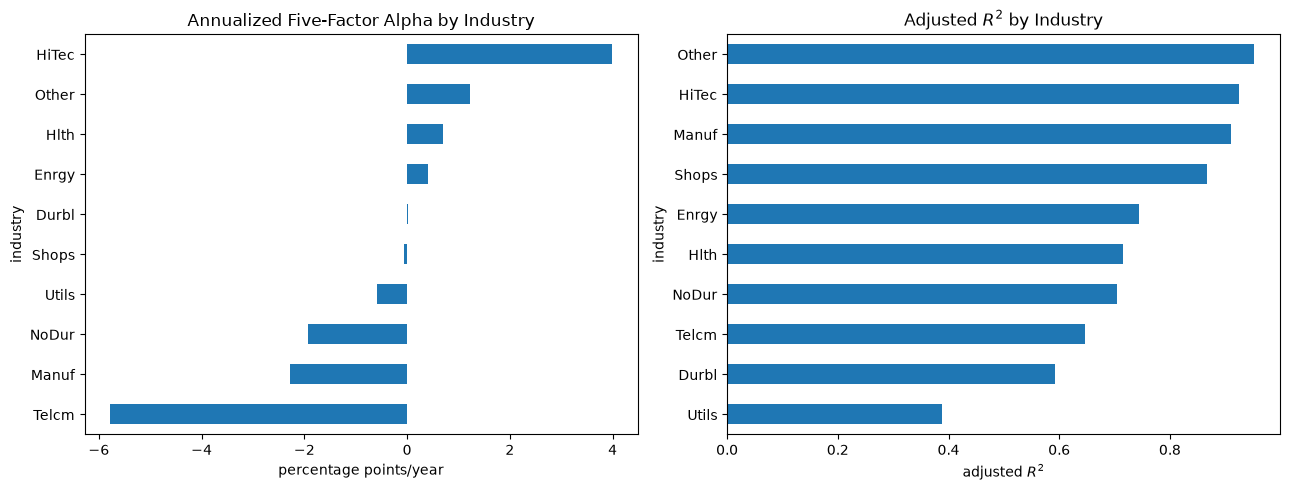

In [3]:
example = "HiTec"
print(results[example].summary())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
summary["alpha_annualized_pct"].sort_values().plot.barh(ax=axes[0])
axes[0].set(title="Annualized Five-Factor Alpha by Industry", xlabel="percentage points/year")
summary["adj_r2"].sort_values().plot.barh(ax=axes[1])
axes[1].set(title="Adjusted $R^2$ by Industry", xlabel="adjusted $R^2$")
plt.tight_layout()
plt.show()


## Key Equations

- **Five-factor regression:** $R_{i,t}-R_{f,t}=\alpha_i+\beta_M MKT_t+\beta_S SMB_t+\beta_H HML_t+\beta_R RMW_t+\beta_C CMA_t+\varepsilon_{i,t}$.
- **Pricing diagnostic:** an economically small and statistically weak $\alpha_i$ is consistent with the factors spanning that portfolio's average excess return over the evaluated sample.
- **Scope:** this lab uses the bundled 2015–2022 overlap and is a reproduction of the factor-model workflow, not the exact sample of Fama and French (2015).


## 3. Interpretation and Replication Boundary
The exercise uses real bundled factor and industry-portfolio data, but the five-factor file starts in 2015. Fama and French (2015) evaluate a much longer historical sample and a broader set of test portfolios. Therefore differences from the published paper are expected and should not be labeled replication failures. This notebook is designed to reproduce the **econometric mechanism and diagnostics** on a transparent local sample.

## Exercises
**1. Factor meaning (Conceptual):** Explain the economic interpretation of each of SMB, HML, RMW, and CMA. Why can a high $R^2$ coexist with a nonzero intercept?

**2. Model comparison (Applied):** Re-estimate every industry using only the market factor and compare adjusted $R^2$, alphas, and residual volatility with the five-factor specification.

**3. Stability (Challenge):** Split the 2015–2022 sample into two subperiods. Quantify which factor loadings are least stable and discuss whether the shift is economic, statistical, or both.

## Summary & Key Takeaways
- Alignment by calendar month is part of the econometric specification, not clerical preprocessing.
- Industry factor loadings differ meaningfully; intercepts and residual diagnostics remain necessary.
- A later-sample reproduction must be clearly separated from an exact paper replication.

## References & Further Reading
- Fama, E. F. & French, K. R. (2015). A five-factor asset pricing model. *Journal of Financial Economics*, 116(1), 1–22.
- Cochrane, J. H. (2005). *Asset Pricing*. Princeton University Press.

**Failure analysis (Challenge):** Replicated alphas are significant but flip sign relative to the paper — factor returns were built with the wrong rebalancing date and a look-ahead in the sort. Diagnose the timing construction, repair to the official convention, and verify correlations with the published factor returns.